# Example: U sorption - cation exchange and surface complexation - using a fictive pH buffer to hold the pH

Authors: G. Dan Miron

In [1]:
## Import python packages
import numpy as np
import xgems as xg
import sys

## Setting global variables, paths

In [2]:
# file name for system definitions
xg_system_filename='gems_files/Exch+SCM-dat.lst'

xgEngine = xg.ChemicalEngine(xg_system_filename)
buffer_G_ideal = xgEngine.standardMolarGibbsEnergy(xgEngine.indexSpecies('pHbufferOHCl'))

## Defining the lists of indexes for elements, substance
- hint these can be kept in a separate python file an used in other projects

In [3]:
# lists of elements and phases
element_symbols = ['Cl', 'Clay','Ess','Esv', 'H', 'Na','O','Pbuff', 'U', 'Zz']
phase_names = {
    'MontX': 'MontX',
    'MonEdS': 'MonEdS',
    'UO2(am,hyd)': 'UO2(am,hyd)',
    'Metaschoepite' : 'Metaschoepite',
    'gas_gen': 'gas',
    'aq_gen': 'aqueous',
}

# dictionary of element names and index
element_indexes = {symbol: xgEngine.indexElement(symbol) for symbol in element_symbols}
# dictionary of phase names and index
phase_indexes = {name: xgEngine.indexPhase(name) for name in phase_names}

In [4]:
# copy from leaching example, add Al, Mg
# Lists of what we will output 
output_aqueous_elements = ['U']
output_properties = [ 'pH', 'gems_code']

In [5]:
# initialize the output containers, also dictionaries
aqueous_table = {element: [] for element in output_aqueous_elements}
properties_table = {prop: [] for prop in output_properties}
solids_volume_table = {phase: [] for phase in phase_names.values()}

grouped_output_phase_indexes = {}
for phase, name in phase_names.items():
    grouped_output_phase_indexes.setdefault(name, []).append(phase_indexes[phase])

In [6]:
# 2. Extract copy of current engine composition vector
# (This ensures the list is the exact size expected by xgEngine)
T = xgEngine.temperature()
P = xgEngine.pressure()
b_buffer = xgEngine.elementAmounts().copy()
b_boundary = xgEngine.elementAmounts().copy()
b_initial = xgEngine.elementAmounts().copy()

# 3. Assign b_buffer elements explicitly using the element_indexes dictionary
b_buffer[element_indexes['Cl']]    = 1
b_buffer[element_indexes['Clay']]  = 0
b_buffer[element_indexes['Ess']]  = 0
b_buffer[element_indexes['Esv']]  = 0
b_buffer[element_indexes['H']]     = 1
b_buffer[element_indexes['Na']]    = 0
b_buffer[element_indexes['O']]     = 2
b_buffer[element_indexes['Pbuff']] = 2
b_buffer[element_indexes['U']]     = 0
b_buffer[element_indexes['Zz']]    = 0

# 4. Assign values for b_boundary 
b_boundary[element_indexes['Cl']]    = 0.1
b_boundary[element_indexes['Clay']]  = 1e-15
b_boundary[element_indexes['Ess']]  = 1e-15
b_boundary[element_indexes['Esv']]  = 1e-15
b_boundary[element_indexes['H']]     = 111.0167
b_boundary[element_indexes['Na']]    = 0.1
b_boundary[element_indexes['O']]     = 55.50857+1
b_boundary[element_indexes['Pbuff']] = 0
b_boundary[element_indexes['U']]     = 1e-4
b_boundary[element_indexes['Zz']]    = 0

# 5. Assign values for b_initial 
b_initial[element_indexes['Cl']]    = 0.1
b_initial[element_indexes['Clay']]  = 0.1
b_initial[element_indexes['Ess']]  = 2e-6
b_initial[element_indexes['Esv']]  = 4e-5
b_initial[element_indexes['H']]     = 111.0167
b_initial[element_indexes['Na']]    = 0.2
b_initial[element_indexes['O']]     = 55.50837+1
b_initial[element_indexes['Pbuff']] = 0
b_initial[element_indexes['U']]     = 1e-9
b_initial[element_indexes['Zz']]    = 0

print(b_initial+b_buffer)

[1.100000e+00 1.000000e-01 2.000000e-06 4.000000e-05 1.120167e+02
 2.000000e-01 5.850837e+01 2.000000e+00 1.000000e-09 0.000000e+00]


In [7]:
# now we suppress the precipitation of solids
xgEngine.setSpeciesUpperLimit("UO2(am,hyd)",0.0)
xgEngine.setSpeciesUpperLimit("Metaschoepite",0.0)

xgEngine.setColdStart()
code = xgEngine.equilibrate(T, P, b_boundary+b_buffer)
if code != 2 and code != 6:
            print("WARNING: Problem with GEMS output code at the beginning...... ")
            sys.exit()

log10_Cl_activity = xgEngine.lnActivities()[xgEngine.indexSpecies('Cl-')]/np.log(10)



In [8]:
# pH buffer logK of pHbufferOHCl is 7 at limit Cl activity 0
# logK pHbufferOHCl = 7 - log10(aCl-) or 7 - ln(aCl-)/ln(10)
# because GEMS uses dGf this change in logK propagates to a correction in dfG of pHbufferOHCl = dGf + R*T*ln(aCl-)
# works without itterations between pH 3-11 IS 0.1

#                      = -ln(10)*R*T*(DpH) 
buffer_G_change_from_7 = -np.log(10)*8.3144*298.15*(0)
buffer_G_corr_Cl = 8.3144*298.15*xgEngine.lnActivities()[xgEngine.indexSpecies('Cl-')]

print(buffer_G_corr_Cl)

-6320.7483715963135


In [9]:
xgEngine.standardMolarGibbsEnergy(xgEngine.indexSpecies('pHbufferOHCl'))

-171246.29421654

In [10]:
xgEngine.setStandardMolarGibbsEnergy('pHbufferOHCl', buffer_G_ideal + buffer_G_corr_Cl + buffer_G_change_from_7)
xgEngine.standardMolarGibbsEnergy(xgEngine.indexSpecies('pHbufferOHCl'))

-177567.0425881363

In [11]:
code = xgEngine.equilibrate(T, P, b_boundary+b_buffer)

In [12]:
print(xgEngine)

Temperature[K]           Temperature[C]           Pressure[MPa]            
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
298.15                   25                       0.1                      
Element                  aq_gen[mol]              gas_gen[mol]             MontX[mol]               MonEdS[mol]              pHbufferO[mol]           pHbufferOHCl[mol]        
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Cl                       1.000308e-01             0.000000e+00             0.000000e+00             0.000000e+00             0.000000e+00             9.999692e-01             
Clay                     0.000000e+00             0.000000e+00             1.000000e-15             0.000000e+00             0.000000e+00       

In [26]:
# pH isotherm 
ndx_aq = phase_indexes['aq_gen']

def isotherm(set_pH, ndxEl, concentration = [-11, -2.9, 0.1]):
    Xaxis = []
    logKd_list = []
    input_el_con = []

    for x in np.arange(concentration[0], concentration[1], concentration[2]):
        concentration = 10**x
        ba = xgEngine.elementAmounts().copy()
        #ba = [el for el in b]
        ba[ndxEl] = concentration
        input_el_con.append(concentration)
            #print(x)
        
        code = xgEngine.equilibrate(298.15, 1e5, ba) # 2 OK, this is available in the output
        #print(xgEngine.pH())

        sorbed_aq = xgEngine.elementAmountsInPhase(ndx_aq)[ndxEl] #moles
        volume_aq = (xgEngine.phaseVolume(ndx_aq)*1e3) # liter
        sorbed_solid = xgEngine.elementAmountsInPhase(phase_indexes['MontX'])[ndxEl]+xgEngine.elementAmountsInPhase(phase_indexes['MonEdS'])[ndxEl]
        clay_mass = xgEngine.phaseMass(phase_indexes['MontX'])

        sorbed_aq = np.log10(sorbed_aq/volume_aq)
        sorbed_solid = np.log10(sorbed_solid)
        clay_mass = np.log10(clay_mass)

        logKd_ = sorbed_solid - clay_mass -sorbed_aq

        Xaxis.append(sorbed_aq)
        #logKd_list.append(logKd_-3) # m3/kg
        logKd_list.append(logKd_) # m3/kg
    return Xaxis, logKd_list

In [27]:
def pH_edge(concentration, ndxEl, pH = [3, 11, 0.1]):
    Xaxis = []
    logKd_list = []
    input_el_con = []

    for x in np.arange(pH[0], pH[1], pH[2]):
        concentration = 10**(-5)
        ba = xgEngine.elementAmounts().copy()
        #ba = [el for el in b]
        ba[ndxEl] = concentration
        input_el_con.append(concentration)

        code = xgEngine.equilibrate(298.15, 1e5, ba) # 2 OK, this is available in the output
        
        buffer_G_corr_Cl = 8.3144*298.15*xgEngine.lnActivities()[xgEngine.indexSpecies('Cl-')]
        buffer_G_change_from_7 = -np.log(10)*8.3144*298.15*((x-7))
            
        xgEngine.setStandardMolarGibbsEnergy('pHbufferOHCl', buffer_G_ideal + buffer_G_corr_Cl+buffer_G_change_from_7 )

        code = xgEngine.equilibrate(298.15, 1e5, ba)
        #print(buffer_G_change_from_7)
        #print(xgEngine.pH())

        sorbed_aq = xgEngine.elementAmountsInPhase(ndx_aq)[ndxEl] #moles
        volume_aq = (xgEngine.phaseVolume(ndx_aq)*1e3) # liter
        sorbed_solid = xgEngine.elementAmountsInPhase(phase_indexes['MontX'])[ndxEl]+xgEngine.elementAmountsInPhase(phase_indexes['MonEdS'])[ndxEl]
        clay_mass = xgEngine.phaseMass(phase_indexes['MontX'])

        sorbed_aq = np.log10(sorbed_aq/volume_aq)
        sorbed_solid = np.log10(sorbed_solid)
        clay_mass = np.log10(clay_mass)

        logKd_ = sorbed_solid - clay_mass -sorbed_aq

        Xaxis.append(xgEngine.pH())
        #logKd_list.append(logKd_-3) # m3/kg
        logKd_list.append(logKd_) # m3/kg
    return Xaxis, logKd_list

In [28]:
Xaxis, logKd_list = isotherm(7, element_indexes['U'])

In [29]:
import matplotlib.pyplot as plt

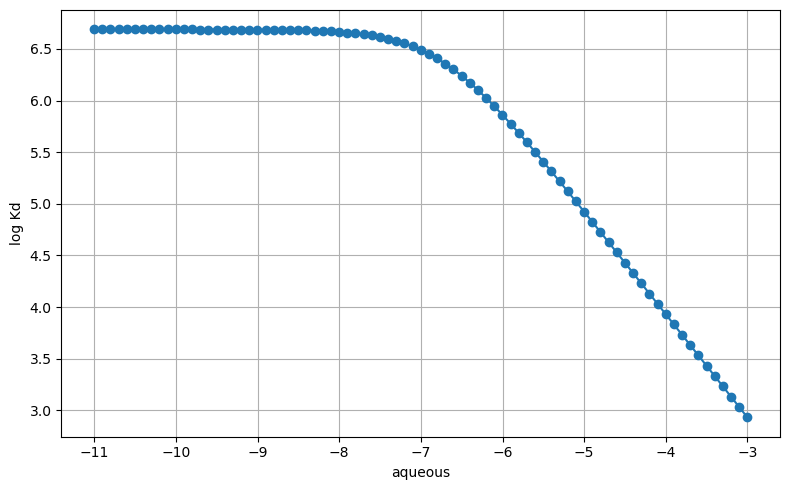

In [30]:
    # --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(Xaxis, logKd_list, marker='o')
plt.xlabel("aqueous")
plt.ylabel("log Kd")
plt.grid(True)
plt.tight_layout()

In [31]:
#xgEngine = xg.ChemicalEngine(xg_system_filename)
#buffer_G_ideal = xgEngine.standardMolarGibbsEnergy(xgEngine.indexSpecies('pHbufferOHCl'))

Xaxis, logKd_list = pH_edge(-8, element_indexes['U'], [2,12.1,0.1])

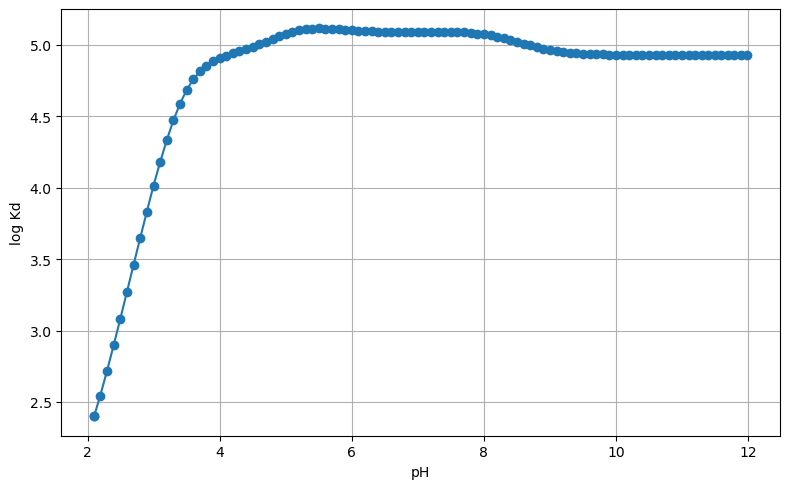

In [32]:
    # --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(Xaxis, logKd_list, marker='o')
plt.xlabel("pH")
plt.ylabel("log Kd")
plt.grid(True)
plt.tight_layout()